# 02 Baseline ML Model for Occupancy

Этот ноутбук строит первый базовый ML‑прогнозатор заполняемости залов (`occupancy_rate`) на основе классического Random Forest. Его задача — быть «оракулом спроса» для последующих оптимизаторов (brute force, CP-SAT, QUBO).

В этом ноутбуке мы:

- Загружаем `data/processed/train.csv`, `validation.csv`, `test.csv` и применяем одну и ту же схему признаков: числовые, категориальные и булевы фичи без leakage.
- Строим sklearn‑pipeline: `ColumnTransformer(StandardScaler + OneHotEncoder)` → `RandomForestRegressor`, и настраиваем гиперпараметры через `RandomizedSearchCV` (4‑fold KFold, MAE).
- Оцениваем качество модели по MAE/RMSE/R² на валидации и тесте, плюс анализируем feature importance и bias по группам (genre, hour_bucket, city, is_weekend, prime_time_flag, формат).
- Сохраняем `final_model` (дообученный на train+validation) в артефакт `artifacts/final_model.joblib` для дальнейшего использования в оптимизационных сценариях.


## Навигация по ноутбуку

### Зачем нужен этот ноутбук
Этот ноутбук обучает базовую ML-модель прогноза спроса / заполняемости. В пайплайне BOQ именно она играет роль оракла, который позже оценивает кандидатов для задачи оптимизации расписания.

### Что здесь самое важное
- Получить понятный и интерпретируемый baseline до более сложных моделей.
- Оценить качество прогноза на временном validation split.
- Сохранить модель, которую затем использует classical и QUBO-оптимизация.

### Какие результаты здесь ключевые
- Метрики baseline-модели на validation.
- Pipeline предобработки и обучения.
- Сериализованный model artifact для downstream-скоринга кандидатов.

### Как читать этот ноутбук
Если оптимизатор даёт странные решения, сначала нужно проверить, насколько разумный прогноз даёт ML-модель. Проблема может быть не в solver, а в слабом или смещённом предсказании
.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

PROCESSED_DIR

PosixPath('/Users/mishatrubik/Desktop/QC/BOQ/data/processed')

In [2]:
train_df = pd.read_csv(PROCESSED_DIR / 'train.csv', parse_dates=['show_datetime'])
val_df = pd.read_csv(PROCESSED_DIR / 'validation.csv', parse_dates=['show_datetime'])
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv', parse_dates=['show_datetime'])

{
    'train_rows': len(train_df),
    'val_rows': len(val_df),
    'test_rows': len(test_df),
}

{'train_rows': 628, 'val_rows': 135, 'test_rows': 135}

In [3]:
TARGET = 'occupancy_rate'
DROP_COLUMNS = ['show_id', 'sold_tickets', 'occupancy_rate']


def make_feature_target_split(df: pd.DataFrame, target: str, drop_columns: list[str]):
    X = df.drop(columns=drop_columns, errors='ignore').copy()
    y = df[target].copy()
    return X, y


X_train = train_df.drop(columns=DROP_COLUMNS, errors='ignore').copy()
y_train = train_df[TARGET].copy()
X_val = val_df.drop(columns=DROP_COLUMNS, errors='ignore').copy()
y_val = val_df[TARGET].copy()
X_test = test_df.drop(columns=DROP_COLUMNS, errors='ignore').copy()
y_test = test_df[TARGET].copy()

{
    'X_train_shape': X_train.shape,
    'X_val_shape': X_val.shape,
    'X_test_shape': X_test.shape,
    'target': TARGET,
}

{'X_train_shape': (628, 22),
 'X_val_shape': (135, 22),
 'X_test_shape': (135, 22),
 'target': 'occupancy_rate'}

In [4]:
numeric_features = [
    'hall_capacity', 'runtime_min', 'base_price',
    'day_of_week', 'month', 'release_age_days', 'lead_time_days',
    'screening_number_for_movie',
]

categorical_features = [
    'cinema_id', 'hall_id', 'movie_id', 'genre', 'age_rating',
    'format', 'city', 'hour_bucket', 'runtime_bucket',
]

boolean_features = ['is_weekend', 'holiday_flag', 'prime_time_flag']

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features + boolean_features),
    ],
)

model = Pipeline([
    ('preprocess', preprocessor),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1)),
])

model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['hall_capacity',
                                                   'runtime_min', 'base_price',
                                                   'day_of_week', 'month',
                                                   'release_age_days',
                                                   'lead_time_days',
                                                   'screening_number_for_movie']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cinema_id', 'hall_id',
                                                   'movie_id', 'genre',
                                                   'age_rating', 'format',
                                                   'city', 'hour_bucket',
                                                   'runtime_bucket',
                                                   'is_weekend', 'holiday_flag',
                                                   'prime_time_flag'])])),
                ('rf', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [6]:
param_distributions = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [5, 10, 15, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
}

param_distributions

{'rf__n_estimators': [100, 200, 300],
 'rf__max_depth': [5, 10, 15, None],
 'rf__min_samples_split': [2, 5, 10],
 'rf__min_samples_leaf': [1, 2, 4]}

In [7]:
from sklearn.model_selection import RandomizedSearchCV, KFold

cv = KFold(n_splits=4, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=10,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

search

RandomizedSearchCV(cv=KFold(n_splits=4, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['hall_capacity',
                                                                                'runtime_min',
                                                                                'base_price',
                                                                                'day_of_week',
                                                                                'month',
                                                                                'release_age_days',
                                                                                'lead_time_days',
                                                                                'screening_number_for_movie']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['cine...
                                                                                'hour_bucket',
                                                                                'runtime_bucket',
                                                                                'is_weekend',
                                                                                'holiday_flag',
                                                                                'prime_time_flag'])])),
                                             ('rf',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'rf__max_depth': [5, 10, 15, None],
                                        'rf__min_samples_leaf': [1, 2, 4],
                                        'rf__min_samples_split': [2, 5, 10],
                                        'rf__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [8]:
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print('Best CV MAE:', -search.best_score_)

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best params: {'rf__n_estimators': 300, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 4, 'rf__max_depth': 15}
Best CV MAE: 0.0781840781725256


In [9]:
best_model = search.best_estimator_
val_pred = best_model.predict(X_val)

val_mae = mean_absolute_error(y_val, val_pred)
val_mse = mean_squared_error(y_val, val_pred)
val_rmse = val_mse ** 0.5
val_r2 = r2_score(y_val, val_pred)

val_metrics = {
    'val_mae': float(val_mae),
    'val_rmse': float(val_rmse),
    'val_r2': float(val_r2),
}
val_metrics

{'val_mae': 0.07155881306279378,
 'val_rmse': 0.08901265460453531,
 'val_r2': 0.8488795060534171}

In [10]:
X_train_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

final_model = search.best_estimator_
final_model.fit(X_train_full, y_train_full)

test_pred = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_pred)
test_mse = mean_squared_error(y_test, test_pred)
test_rmse = test_mse ** 0.5
test_r2 = r2_score(y_test, test_pred)

test_metrics = {
    'test_mae': float(test_mae),
    'test_rmse': float(test_rmse),
    'test_r2': float(test_r2),
}
test_metrics

{'test_mae': 0.07180719352408403,
 'test_rmse': 0.08774396462683058,
 'test_r2': 0.8498005257242731}

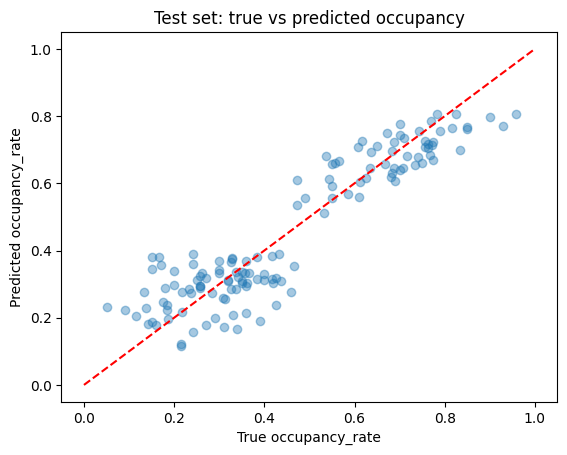

In [11]:
fig, ax = plt.subplots()
ax.scatter(y_test, test_pred, alpha=0.4)
ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlabel('True occupancy_rate')
ax.set_ylabel('Predicted occupancy_rate')
ax.set_title('Test set: true vs predicted occupancy')
plt.show()

## Error analysis and feature importance

Ниже — базовый пост-анализ baseline модели: какие признаки важны, по каким группам растёт ошибка и в каких конкретных show-level кейсах модель промахивается сильнее всего.


In [12]:
rf = final_model.named_steps['rf']
preprocess = final_model.named_steps['preprocess']

ohe = preprocess.named_transformers_['cat']
cat_bool_features = categorical_features + boolean_features
ohe_feature_names = ohe.get_feature_names_out(cat_bool_features).tolist()
feature_names = numeric_features + ohe_feature_names

feature_importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(20)

,feature,importance
0,prime_time_flag_False,0.384903
1,prime_time_flag_True,0.254485
2,release_age_days,0.121660
3,hour_bucket_evening,0.076464
4,base_price,0.021108
5,lead_time_days,0.017436
6,hour_bucket_day,0.017124
7,screening_number_for_movie,0.015714
8,day_of_week,0.015395
9,is_weekend_True,0.009948


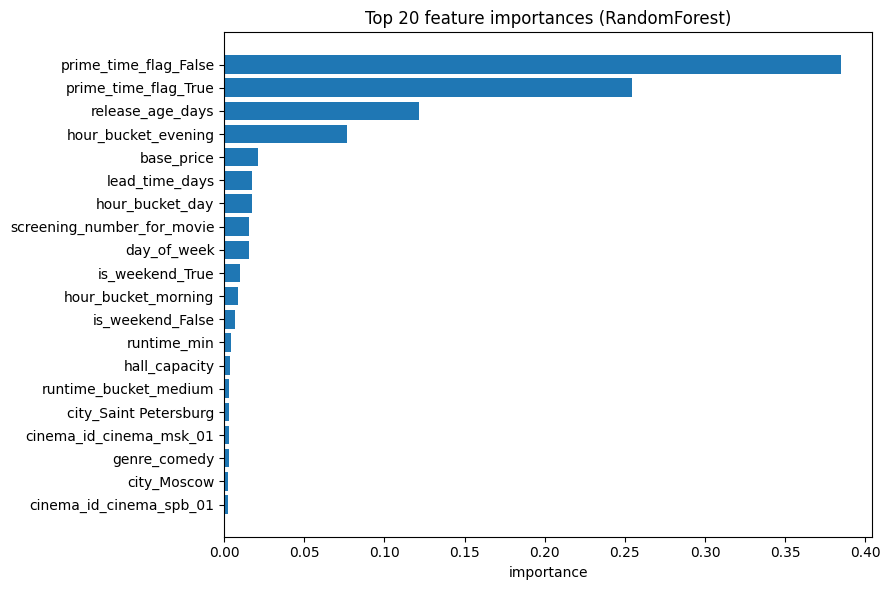

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
top_k = 20
top_fi = feature_importance_df.head(top_k).iloc[::-1]
ax.barh(top_fi['feature'], top_fi['importance'])
ax.set_title('Top 20 feature importances (RandomForest)')
ax.set_xlabel('importance')
plt.tight_layout()
plt.show()

In [14]:
test_df_with_pred = test_df.copy()
test_df_with_pred['y_true'] = y_test.values
test_df_with_pred['y_pred'] = test_pred
test_df_with_pred['abs_error'] = (test_df_with_pred['y_true'] - test_df_with_pred['y_pred']).abs()
test_df_with_pred['signed_error'] = test_df_with_pred['y_pred'] - test_df_with_pred['y_true']

test_df_with_pred.head()

,show_id,cinema_id,hall_id,hall_capacity,movie_id,genre,age_rating,runtime_min,release_date,show_datetime,...,holiday_flag,release_age_days,lead_time_days,prime_time_flag,runtime_bucket,screening_number_for_movie,y_true,y_pred,abs_error,signed_error
0,show_00460,cinema_msk_01,hall_2,80,movie_comedy_01,comedy,12+,105,2026-02-10,2026-04-22 11:15:00,...,False,71,13.7,False,medium,115,0.1375,0.230025,0.092525,0.092525
1,show_00849,cinema_spb_01,hall_2,70,movie_family_01,animation,6+,92,2026-02-20,2026-04-22 11:30:00,...,False,61,14.5,False,medium,57,0.1429,0.182391,0.039491,0.039491
2,show_00463,cinema_msk_01,hall_3,60,movie_dune_2,sci_fi,16+,166,2026-03-01,2026-04-22 11:30:00,...,False,52,12.5,False,long,112,0.1333,0.277686,0.144386,0.144386
3,show_00457,cinema_msk_01,hall_1,120,movie_dune_2,sci_fi,16+,166,2026-03-01,2026-04-22 14:15:00,...,False,52,13.3,False,long,110,0.3000,0.343424,0.043424,0.043424
4,show_00461,cinema_msk_01,hall_2,80,movie_horror_01,horror,18+,98,2026-03-05,2026-04-22 14:15:00,...,False,48,13.9,False,medium,123,0.4375,0.308574,0.128926,-0.128926


In [15]:
def group_error(df: pd.DataFrame, by_cols: list[str]) -> pd.DataFrame:
    return (
        df.groupby(by_cols, dropna=False)['abs_error']
        .agg(['count', 'mean', 'median', 'max'])
        .sort_values('mean', ascending=False)
        .reset_index()
    )

err_by_genre = group_error(test_df_with_pred, ['genre'])
err_by_hour_bucket = group_error(test_df_with_pred, ['hour_bucket'])
err_by_city = group_error(test_df_with_pred, ['city'])
err_by_weekend = group_error(test_df_with_pred, ['is_weekend'])
err_by_prime_time = group_error(test_df_with_pred, ['prime_time_flag'])
err_by_format = group_error(test_df_with_pred, ['format'])

err_by_genre, err_by_hour_bucket, err_by_city

(       genre  count      mean    median       max
 0     horror     32  0.075958  0.064220  0.212582
 1     sci_fi     32  0.075772  0.055562  0.201044
 2  animation     36  0.069051  0.058533  0.229655
 3     comedy     35  0.067222  0.064333  0.186853,
   hour_bucket  count      mean    median       max
 0     morning     43  0.091412  0.084334  0.229655
 1     evening     47  0.064510  0.059072  0.158650
 2         day     45  0.060695  0.046750  0.194862,
                city  count      mean    median       max
 0            Moscow     84  0.072819  0.059001  0.229655
 1  Saint Petersburg     51  0.070141  0.060325  0.201044)

In [16]:
err_by_weekend, err_by_prime_time, err_by_format

(   is_weekend  count      mean    median       max
 0        True     30  0.075443  0.057421  0.229655
 1       False    105  0.070768  0.059072  0.201044,
    prime_time_flag  count      mean    median       max
 0            False     83  0.076595  0.063088  0.229655
 1             True     52  0.064166  0.058778  0.158650,
   format  count      mean    median       max
 0   IMAX     45  0.083966  0.070571  0.212582
 1     2D     45  0.071453  0.058992  0.229655
 2     3D     45  0.060003  0.051252  0.158650)

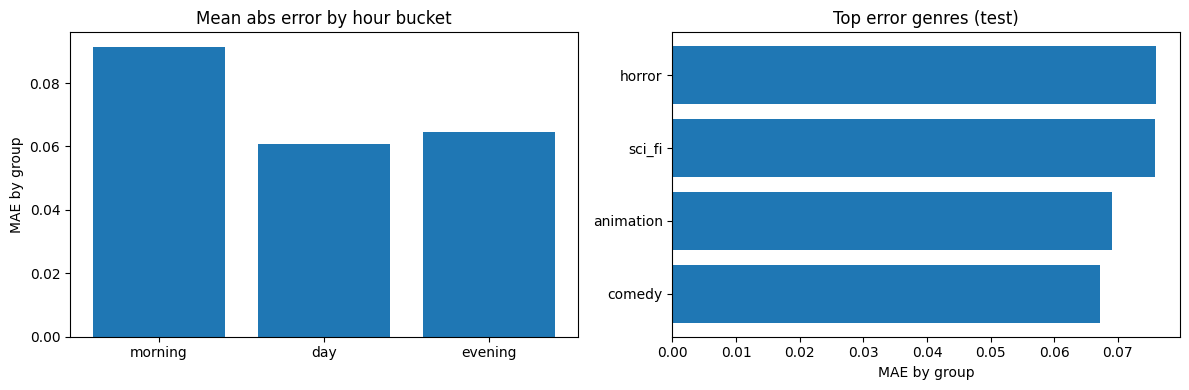

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hour_order = ['morning', 'day', 'evening']
hour_plot = err_by_hour_bucket.set_index('hour_bucket').reindex(hour_order)
axes[0].bar(hour_plot.index.astype(str), hour_plot['mean'])
axes[0].set_title('Mean abs error by hour bucket')
axes[0].set_ylabel('MAE by group')

genre_plot = err_by_genre.head(8).sort_values('mean', ascending=True)
axes[1].barh(genre_plot['genre'], genre_plot['mean'])
axes[1].set_title('Top error genres (test)')
axes[1].set_xlabel('MAE by group')

plt.tight_layout()
plt.show()

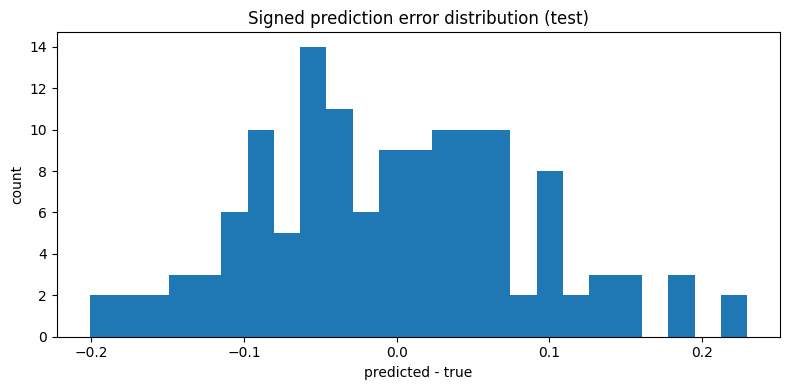

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_df_with_pred['signed_error'], bins=25)
ax.set_title('Signed prediction error distribution (test)')
ax.set_xlabel('predicted - true')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [19]:
top_misses = (
    test_df_with_pred
    .sort_values('abs_error', ascending=False)
    .head(20)[[
        'show_id', 'cinema_id', 'hall_id', 'movie_id', 'genre', 'format', 'city',
        'show_datetime', 'y_true', 'y_pred', 'abs_error', 'signed_error'
    ]]
    .reset_index(drop=True)
)

top_misses

,show_id,cinema_id,hall_id,movie_id,genre,format,city,show_datetime,y_true,y_pred,abs_error,signed_error
0,show_00497,cinema_msk_01,hall_2,movie_family_01,animation,2D,Moscow,2026-04-26 11:45:00,0.1500,0.379655,0.229655,0.229655
1,show_00491,cinema_msk_01,hall_3,movie_horror_01,horror,IMAX,Moscow,2026-04-25 11:30:00,0.1667,0.379282,0.212582,0.212582
2,show_00880,cinema_spb_01,hall_1,movie_dune_2,sci_fi,2D,Saint Petersburg,2026-04-28 11:15:00,0.3900,0.188956,0.201044,-0.201044
3,show_00484,cinema_msk_01,hall_3,movie_horror_01,horror,IMAX,Moscow,2026-04-24 14:15:00,0.1500,0.344862,0.194862,0.194862
4,show_00525,cinema_msk_01,hall_2,movie_comedy_01,comedy,IMAX,Moscow,2026-04-29 11:00:00,0.4250,0.238147,0.186853,-0.186853
5,show_00867,cinema_spb_01,hall_1,movie_family_01,animation,IMAX,Saint Petersburg,2026-04-26 11:15:00,0.1700,0.355883,0.185883,0.185883
6,show_00503,cinema_msk_01,hall_1,movie_comedy_01,comedy,2D,Moscow,2026-04-27 11:15:00,0.0500,0.231776,0.181776,0.181776
7,show_00531,cinema_msk_01,hall_1,movie_dune_2,sci_fi,IMAX,Moscow,2026-04-30 11:30:00,0.4583,0.277360,0.180940,-0.180940
8,show_00873,cinema_spb_01,hall_1,movie_dune_2,sci_fi,2D,Saint Petersburg,2026-04-27 11:00:00,0.3400,0.165529,0.174471,-0.174471
9,show_00872,cinema_spb_01,hall_2,movie_family_01,animation,3D,Saint Petersburg,2026-04-26 19:30:00,0.9286,0.769950,0.158650,-0.158650


In [20]:
from pathlib import Path
import joblib

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACTS_DIR / 'final_model.joblib'
joblib.dump(final_model, MODEL_PATH)

MODEL_PATH


PosixPath('/Users/mishatrubik/Desktop/QC/BOQ/artifacts/final_model.joblib')